# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
expressao = np.random.normal(loc=0, scale=1, size=1000)
expressao

array([-5.59378835e-01,  8.27582934e-01,  1.41413609e+00, -9.16050150e-01,
        5.49200519e-01,  4.42992159e-01, -5.55448459e-01,  6.22587979e-01,
       -1.12692437e-01, -3.91011769e-01, -8.72484991e-01, -2.81518918e-01,
        4.77524305e-01,  6.03317923e-01,  5.69537967e-01,  8.91575048e-01,
        1.85277071e+00, -2.62204268e-01, -5.21262368e-01,  6.38091504e-01,
        9.51326604e-01, -1.19997991e+00, -3.79801461e-01,  5.29398941e-02,
        2.38556139e+00,  5.27489677e-01,  4.04868939e-02,  1.60661439e-01,
       -3.90143225e-01, -1.13421210e+00, -1.08493114e+00, -3.73811206e-01,
        6.28670767e-02,  1.49758148e+00,  8.37503052e-01, -1.29139281e-01,
       -1.06842890e-01,  1.06295500e+00, -2.12841622e+00,  8.93534955e-01,
        1.80104531e+00, -9.85461407e-02,  9.08367676e-01,  1.80084674e+00,
       -2.03184165e+00, -8.66435961e-01, -9.21998518e-01,  1.68511541e-01,
       -1.05363621e+00,  1.44821128e+00, -1.31494121e-01,  6.23724771e-01,
        3.10305599e-01,  

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [9]:
import pandas as pd

dif_expressos = np.random.randint (1, 100, size=1000)
print(dif_expressos)


[30 20 46 40 52 42 22 32 82 43 48 56 65 42  2 97 12 58 19 24 49 72 66 22
 44 81 48  1 47 87 87 94 21 34 99 82 87 68 25 24 20 40 55 11 15 77 10 63
 91 46 27 29 13  7 16 42 10 42 72 18 35 96 97 36 63 52 60 51 47 81 12 19
 99 92 90 15 36 28 95 79  2  9  7 23 49 33 64 35 41 79 18 89 81 19 88 50
 29 48 26  8 83 54 34 13 43 63 43 75 99 91 72 78  4 85 44 17 19 74 19 58
 53 73 84 92 72 34 75  6 96 18 73 68 24 78 81 10 76 48 95 99 12 81 85 70
 86 23 62  6 52 57 94 18 29 55 41 85 92 31 33 25 15 28 58 24  8 62  7 53
 20 42 50 77 70 95 35 92 36 44 74 81 20 80 23 15 24 61 19 97 11 78 38 87
 69 48 10 75 47  9 93 43 66 23 50 20 43 45  3 25 96 42 21 88 85  2  9 63
 17 52 19 73 22 39 64 78 65 56  9 68 19 27 36 82  3 50 25 11 77 64 70 95
 35 50 68 16 53 93 20 81 49 99 97 57 69 38 90  3 37 77 88 64 92 86 86 14
 78 54 74 83 73 11 31 19 89  8 75 73 44 84 69 49 30 38 84 25 27 56 92 31
 81 53 52 45 10 81 83 80 80 86 53 12 86 57 12  8  6 41 70 42 52 39  1 93
 15 55 49 49 25 27 12 41 69 24 38 30 80 46 27 48 65

In [14]:
n_pacientes = 1000

# Número de genes upregulated por paciente
up_genes = np.random.randint(low=0, high=500, size=n_pacientes)

# Número de genes downregulated por paciente
down_genes = np.random.randint(low=0, high=500, size=n_pacientes)

df = pd.DataFrame({
    "Expressao_genica": expressao,
    "Genes_upregulated": up_genes,
    "Genes_downregulated": down_genes
})

print(df.head())

   Expressao_genica  Genes_upregulated  Genes_downregulated
0         -0.559379                248                  200
1          0.827583                201                  142
2          1.414136                387                   12
3         -0.916050                105                   72
4          0.549201                369                  221


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados foram divididos em seis grupos com base na diferença entre o número de genes upregulated e downregulated em cada paciente. Para isso, foi calculado um valor (up − down), em que números positivos indicam mais genes ativados e números negativos indicam mais genes reprimidos. Em seguida, esses valores foram separados em seis faixas, formando grupos que vão de pacientes com maior predominância de genes downregulated até aqueles com maior predominância de genes upregulated. Esse critério foi escolhido porque resume o comportamento geral da expressão gênica de forma simples, facilitando a comparação entre os pacientes.

In [19]:
# Criar um score biológico
df["score"] = df["Genes_upregulated"] - df["Genes_downregulated"]

# Criar 6 grupos
df["grupo"] = pd.cut(df["score"], bins=6, labels=[
    "Muito downregulated",
    "Downregulated",
    "Levemente down",
    "Levemente up",
    "Upregulated",
    "Muito upregulated"
])

print(df.head())

print(tabela_frequencia_simples(df["grupo"]))


   Expressao_genica  Genes_upregulated  Genes_downregulated  score  \
0         -0.559379                248                  200     48   
1          0.827583                201                  142     59   
2          1.414136                387                   12    375   
3         -0.916050                105                   72     33   
4          0.549201                369                  221    148   

               grupo  
0       Levemente up  
1       Levemente up  
2  Muito upregulated  
3       Levemente up  
4       Levemente up  
grupo
Levemente down         272
Levemente up           253
Downregulated          187
Upregulated            150
Muito downregulated     83
Muito upregulated       55
Name: count, dtype: int64


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [23]:
def tabela_frequencia(serie, bins=None):
    if bins is not None:
        serie = pd.cut(serie, bins=bins)
    
    freq_abs = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()
    
    return pd.DataFrame({
        "Frequência Absoluta": freq_abs,
        "Frequência Relativa": freq_rel
    })

tabela_frequencia(df["Expressao_genica"], bins=10)

,Frequência Absoluta,Frequência Relativa
Expressao_genica,,
"(-3.436, -2.799]",5,0.005
"(-2.799, -2.168]",11,0.011
"(-2.168, -1.537]",48,0.048
"(-1.537, -0.906]",121,0.121
"(-0.906, -0.274]",211,0.211
"(-0.274, 0.357]",268,0.268
"(0.357, 0.988]",198,0.198
"(0.988, 1.619]",89,0.089
"(1.619, 2.25]",38,0.038


In [24]:
tabela_frequencia(df["Genes_upregulated"])

,Frequência Absoluta,Frequência Relativa
Genes_upregulated,,
0,1,0.001
1,1,0.001
2,1,0.001
3,2,0.002
4,2,0.002
...,...,...
495,3,0.003
496,2,0.002
497,4,0.004


In [25]:
tabela_frequencia(df["Genes_downregulated"])

,Frequência Absoluta,Frequência Relativa
Genes_downregulated,,
0,3,0.003
1,1,0.001
2,3,0.003
3,1,0.001
4,4,0.004
...,...,...
494,2,0.002
496,3,0.003
497,4,0.004


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [26]:
freq_exp = tabela_frequencia(df["Expressao_genica"], bins=10)

### Expressão

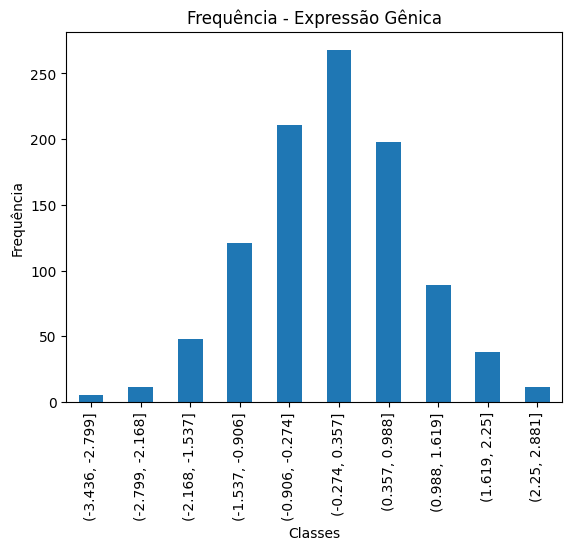

In [27]:
import matplotlib.pyplot as plt

freq_exp["Frequência Absoluta"].plot(kind="bar")
plt.title("Frequência - Expressão Gênica")
plt.xlabel("Classes")
plt.ylabel("Frequência")
plt.show()

### Número

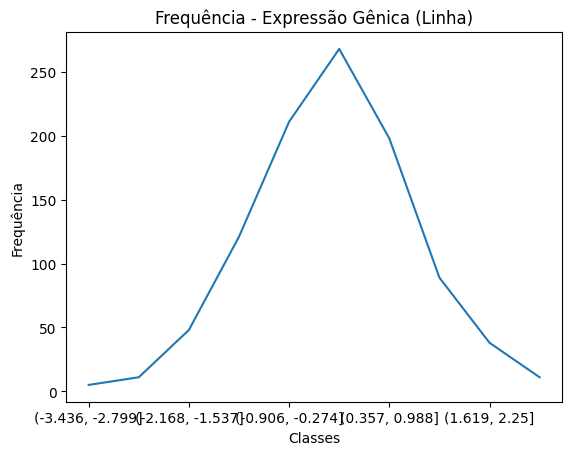

In [28]:
freq_exp["Frequência Absoluta"].plot(kind="line")
plt.title("Frequência - Expressão Gênica (Linha)")
plt.xlabel("Classes")
plt.ylabel("Frequência")
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

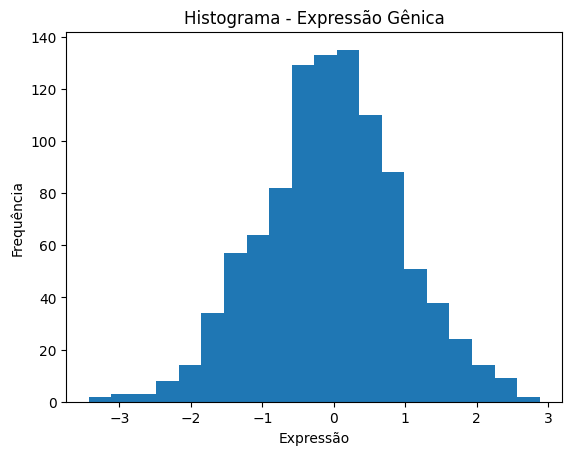

In [29]:
import matplotlib.pyplot as plt

plt.hist(df["Expressao_genica"], bins=20)
plt.title("Histograma - Expressão Gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")
plt.show()

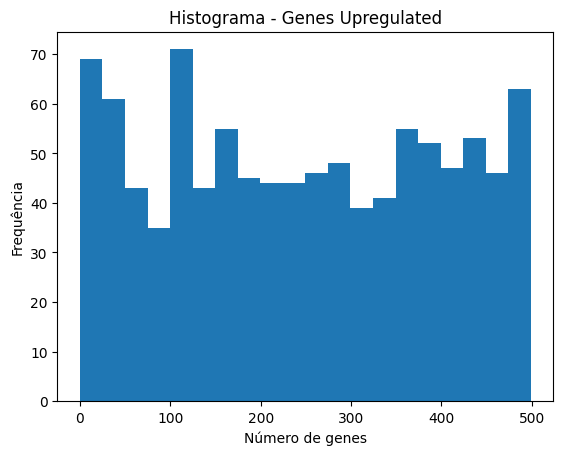

In [30]:
plt.hist(df["Genes_upregulated"], bins=20)
plt.title("Histograma - Genes Upregulated")
plt.xlabel("Número de genes")
plt.ylabel("Frequência")
plt.show()

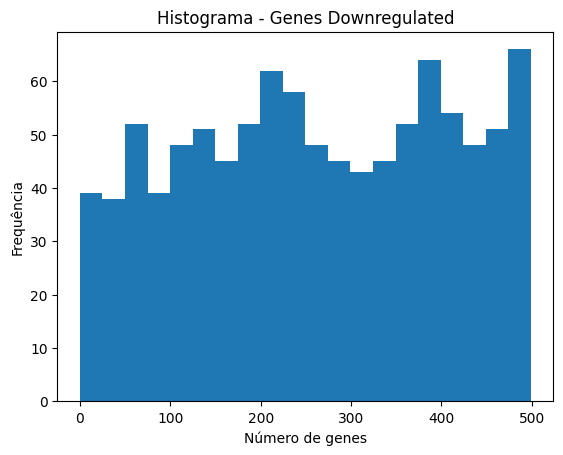

In [31]:
plt.hist(df["Genes_downregulated"], bins=20)
plt.title("Histograma - Genes Downregulated")
plt.xlabel("Número de genes")
plt.ylabel("Frequência")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

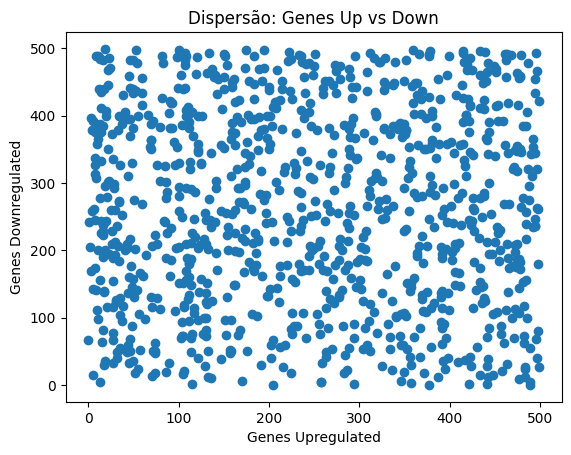

In [32]:
import matplotlib.pyplot as plt

plt.scatter(df["Genes_upregulated"], df["Genes_downregulated"])
plt.title("Dispersão: Genes Up vs Down")
plt.xlabel("Genes Upregulated")
plt.ylabel("Genes Downregulated")
plt.show()

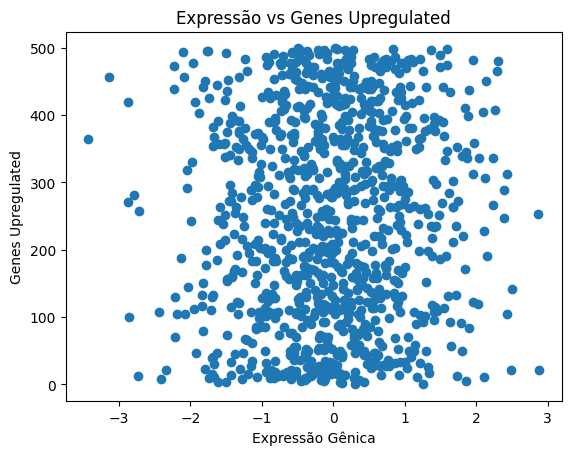

In [33]:
plt.scatter(df["Expressao_genica"], df["Genes_upregulated"])
plt.title("Expressão vs Genes Upregulated")
plt.xlabel("Expressão Gênica")
plt.ylabel("Genes Upregulated")
plt.show()

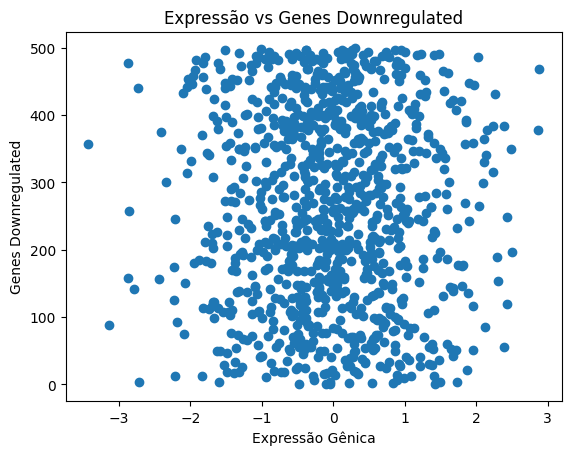

In [34]:
plt.scatter(df["Expressao_genica"], df["Genes_downregulated"])
plt.title("Expressão vs Genes Downregulated")
plt.xlabel("Expressão Gênica")
plt.ylabel("Genes Downregulated")
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

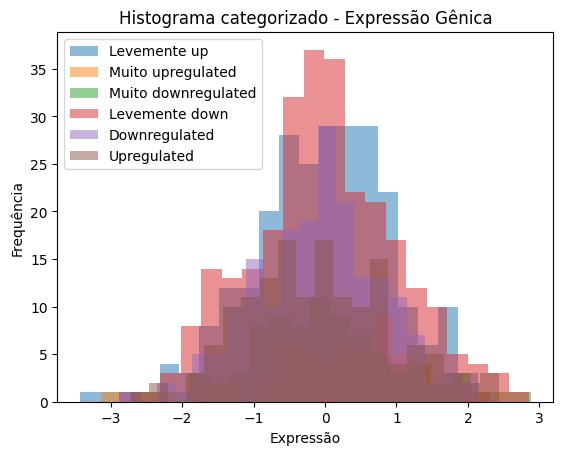

In [37]:
df["score"] = df["Genes_upregulated"] - df["Genes_downregulated"]

df["grupo"] = pd.cut(df["score"], bins=6, labels=[
    "Muito downregulated",
    "Downregulated",
    "Levemente down",
    "Levemente up",
    "Upregulated",
    "Muito upregulated"
])

import matplotlib.pyplot as plt

for grupo in df["grupo"].unique():
    subset = df[df["grupo"] == grupo]
    plt.hist(subset["Expressao_genica"], bins=20, alpha=0.5, label=grupo)

plt.title("Histograma categorizado - Expressão Gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

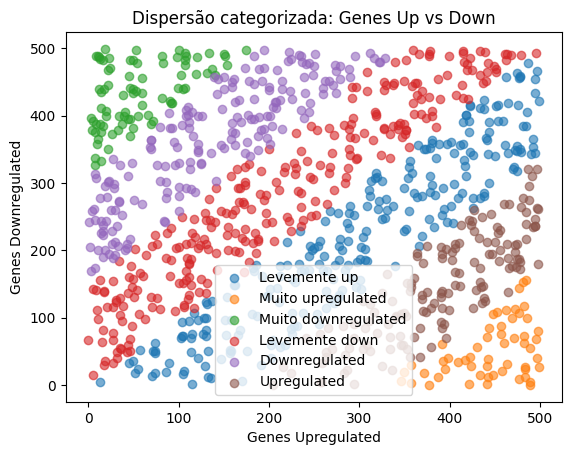

In [40]:

for grupo in df["grupo"].unique():
    subset = df[df["grupo"] == grupo]
    plt.scatter(
        subset["Genes_upregulated"],
        subset["Genes_downregulated"],
        label=grupo,
        alpha=0.6
    )

plt.title("Dispersão categorizada: Genes Up vs Down")
plt.xlabel("Genes Upregulated")
plt.ylabel("Genes Downregulated")
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

R.: | # de células positivas -> discreta | % de células positivas -> contínua | Faixa de pH -> ordinal | Valor de pH -> contínua | mol/L -> contínua | UFC -> discreta | D.O. -> contínua | Grupo Sanguíneo -> nominal | Sorologia -> nominal